<a href="https://colab.research.google.com/github/NEFAxRAJ/Machine-Learning-Practices/blob/main/Hierarchical_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

####**B6. Implement a hierarchical clustering algorithm and display the clustering results using a Dendrogram or a Venn Diagram.**

**Hierarchical clustering** is an unsupervised method that creates a hierarchy of clusters using distance measures and linkage criteria, visualized by a dendrogram.

Unlike partition-based methods (such as K-means), hierarchical clustering does not require the number of clusters to be specified in advance. Instead, it produces a tree-like structure called a dendrogram, which represents the sequence of cluster merges or splits.

The similarity between clusters is determined using a distance metric, most commonly the Euclidean distance

To measure the distance between two clusters, a linkage criterion is used

**Single-Linkage Distance Between Clusters**

For any two clusters \( C_p \) and \( C_q \), the single-linkage distance is defined as

$
d_{\text{single}}(C_p, C_q)
=
\min_{x_i \in C_p,\; x_j \in C_q}
d(x_i, x_j),
$

where d(.,.) is the Euclidean distance given by
$
d(x_i, x_j)
=
\sqrt{\sum_{k=1}^{d} \left(x_{ik} - x_{jk}\right)^2 }
$


**Cluster Merging Criterion**

At each iteration, the pair of clusters \( (C_p, C_q) \) chosen for merging satisfies

$
(C_p, C_q)
=
\arg\min_{p \neq q}
d_{\text{single}}(C_p, C_q).
$

**Cluster Update Rule**

After merging clusters $ C_p  and  C_q $, the new cluster is

$C_{\text{new}} = C_p \cup C_q.
$

The total number of points in the new cluster is
$
\lvert C_{\text{new}} \rvert
=
\lvert C_p \rvert + \lvert C_q \rvert.
$

**Linkage Matrix Representation**

Each merge operation is recorded as a linkage row:
$Linkage Row
=
\left[
C_p,\;
C_q,\;
d_{\text{single}}(C_p, C_q),\;
\lvert C_{\text{new}} \rvert
\right].$


The complete linkage matrix is given by
$
L \in \mathbb{R}^{(n-1) \times 4}.
$

The complete linkage matrix is given by
$
L \in \mathbb{R}^{(n-1) \times 4}.
$

**Termination Condition**

The algorithm stops when all data points are merged into a single cluster:
$
\lvert \mathcal{C} \rvert = 1.
$







In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# Simple 2D dataset
X = np.array([
    [1, 2],
    [2, 2],
    [5, 6],
    [6, 5],
    [8, 8]
])



Euclidean Distance Formula

The Euclidean distance between two data points

$d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$

In [ ]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))


Pairwise Distance Matrix

Given a dataset
$X = \{x_1, x_2, \ldots, x_n\}, \quad x_i \in \mathbb{R}^d$


the distance matrix
$
D \in \mathbb{R}^{n \times n}
$

is defined as
$
D_{ij} = d(x_i, x_j)$
$

In [ ]:
def distance_matrix(X):
    n = len(X)
    dist = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            dist[i, j] = euclidean_distance(X[i], X[j])

    return dist


In [ ]:
def hierarchical_clustering(X):
    n = len(X)
    clusters = {i: [i] for i in range(n)}
    dist_mat = distance_matrix(X)

    linkage_matrix = []
    current_cluster_id = n

    while len(clusters) > 1:
        min_dist = float("inf")
        pair = None

        keys = list(clusters.keys())

        # Find closest pair of clusters
        for i in range(len(keys)):
            for j in range(i + 1, len(keys)):
                c1, c2 = keys[i], keys[j]

                # Single linkage
                for p1 in clusters[c1]:
                    for p2 in clusters[c2]:
                        if dist_mat[p1][p2] < min_dist:
                            min_dist = dist_mat[p1][p2]
                            pair = (c1, c2)

        c1, c2 = pair
        new_cluster = clusters[c1] + clusters[c2]

        linkage_matrix.append([c1, c2, min_dist, len(new_cluster)])

        del clusters[c1]
        del clusters[c2]
        clusters[current_cluster_id] = new_cluster
        current_cluster_id += 1

    return np.array(linkage_matrix)


In [ ]:
Z = hierarchical_clustering(X)
print(Z)


[[0.         1.         1.         2.        ]
 [2.         3.         1.41421356 2.        ]
 [4.         6.         3.60555128 3.        ]
 [5.         7.         5.         5.        ]]


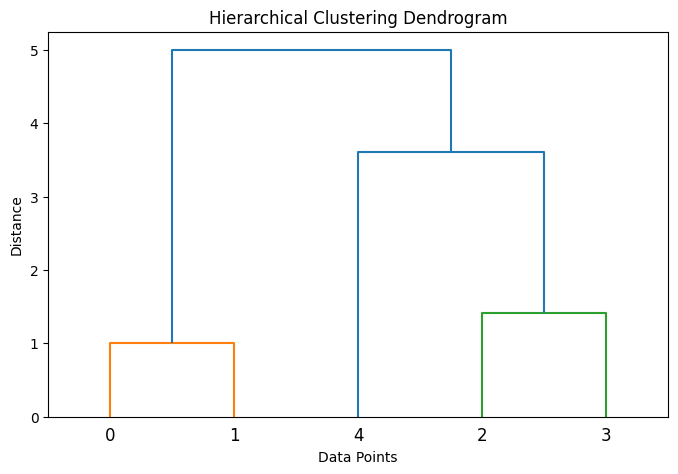

In [ ]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()
